<a href="https://colab.research.google.com/github/chithra-project1/project/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HR_Employee_Attrition(1).csv to HR_Employee_Attrition(1).csv


In [ ]:
import os
print(os.listdir())


['.config', 'HR_Employee_Attrition(1).csv', 'sample_data']


In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('HR_Employee_Attrition(1).csv')

# Display First 5 Rows
print("Dataset Preview")
print(df.head())

Dataset Preview
   EmployeeID EmployeeName Department Salary slab  Years at Company  \
0         101        Arjun      Sales         Low                 2   
1         102        Priya         HR      Medium                 5   
2         103     Karthick        R&D        High                 8   
3         104        Divya      Sales         Low                 1   
4         105        Rahul         HR      Medium                 4   

   Monthly income Attrition  
0           25000       Yes  
1           40000        No  
2           65000        No  
3           22000       Yes  
4           38000        No  


In [ ]:
# Dataset Information
print("\nDataset Info")
print(df.info())
# Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())
# Remove Duplicate Records
df.drop_duplicates(inplace=True)
# Fill Missing Values (if any)
df.fillna(method='ffill', inplace=True)

print("\nData Cleaning Completed")


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EmployeeID        30 non-null     int64 
 1   EmployeeName      30 non-null     object
 2   Department        30 non-null     object
 3   Salary slab       30 non-null     object
 4   Years at Company  30 non-null     int64 
 5   Monthly income    30 non-null     int64 
 6   Attrition         30 non-null     object
dtypes: int64(3), object(4)
memory usage: 1.8+ KB
None

Missing Values
EmployeeID          0
EmployeeName        0
Department          0
Salary slab         0
Years at Company    0
Monthly income      0
Attrition           0
dtype: int64

Data Cleaning Completed


/tmp/ipykernel_618/2530905822.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
# -----------------------------
# ATTRITION ANALYSIS
# -----------------------------

# Overall Attrition Count
print("\nAttrition Count")
print(df['Attrition'].value_counts())


Attrition Count
Attrition
No     19
Yes    11
Name: count, dtype: int64


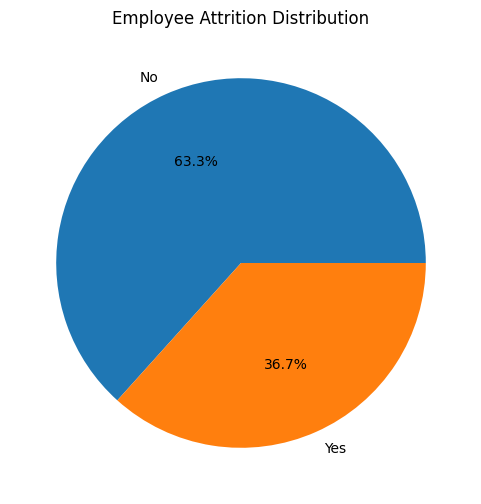

In [ ]:
# Pie Chart - Attrition Distribution
plt.figure(figsize=(6,6))
df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Employee Attrition Distribution')
plt.ylabel('')
plt.show()


Department-wise Attrition
Attrition   No  Yes
Department         
HR           7    3
R&D          9    0
Sales        3    8


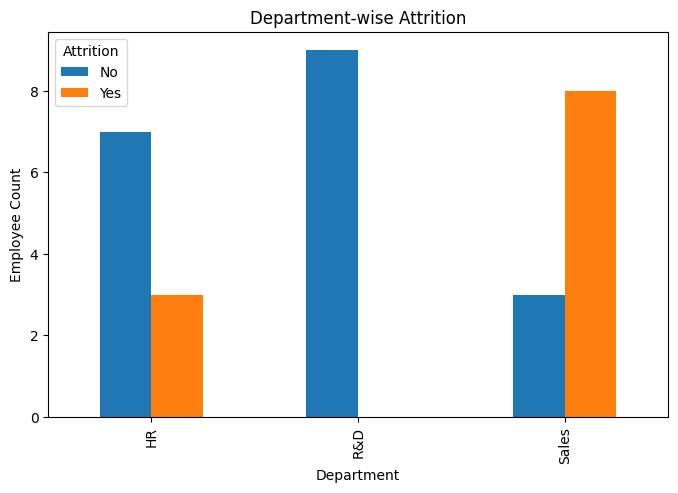

In [ ]:
# -----------------------------
# Department-wise Attrition
# -----------------------------

dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

print("\nDepartment-wise Attrition")
print(dept_attrition)

dept_attrition.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Department-wise Attrition')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.show()


Salary-wise Attrition
Attrition    No  Yes
Salary slab         
High          8    1
Low           4    7
Medium        7    3


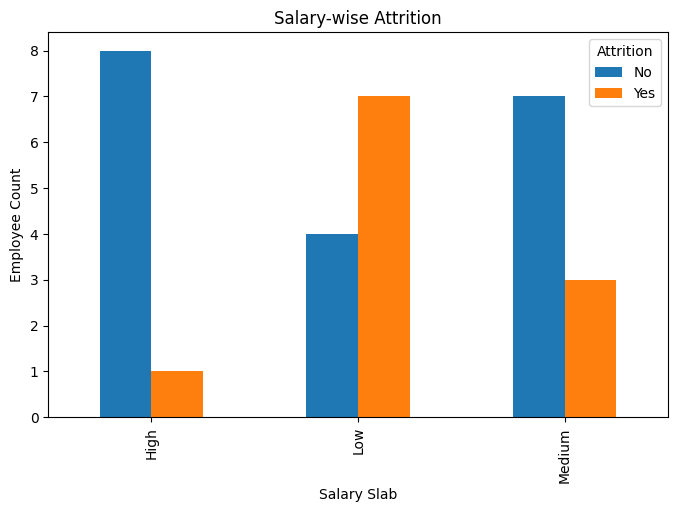

In [ ]:
# Salary-wise Attrition Analysis

salary_attrition = pd.crosstab(
    df['Salary slab'],
    df['Attrition']
)

print("\nSalary-wise Attrition")
print(salary_attrition)

salary_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Salary-wise Attrition')
plt.xlabel('Salary Slab')
plt.ylabel('Employee Count')
plt.show()


Experience-wise Attrition
Attrition          No  Yes
Years at Company          
1                 1.0  2.0
2                 NaN  5.0
3                 NaN  3.0
4                 2.0  NaN
5                 4.0  NaN
6                 2.0  1.0
7                 2.0  NaN
8                 2.0  NaN
9                 2.0  NaN
10                2.0  NaN
11                1.0  NaN
12                1.0  NaN


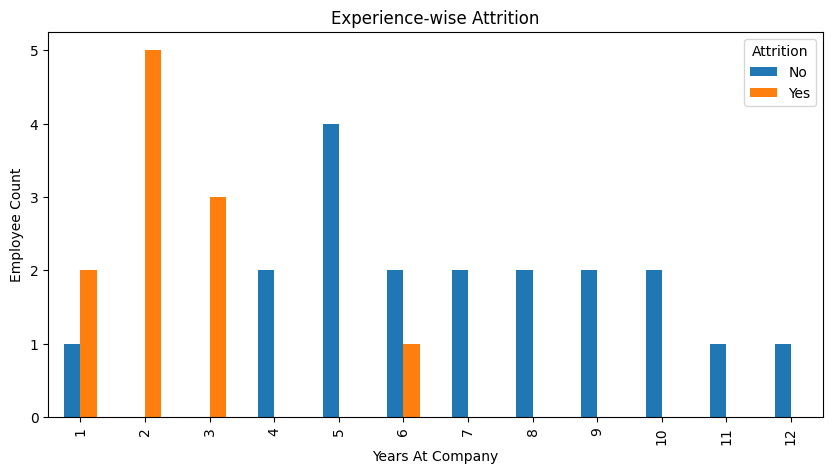

In [ ]:
# -----------------------------
# Experience-wise Attrition
# -----------------------------

experience_attrition = df.groupby(
    'Years at Company'
)['Attrition'].value_counts().unstack()

print("\nExperience-wise Attrition")
print(experience_attrition)

experience_attrition.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Experience-wise Attrition')
plt.xlabel('Years At Company')
plt.ylabel('Employee Count')
plt.show()

In [ ]:
# -----------------------------
# Key Factors
# -----------------------------

print("\nAverage Monthly Income by Attrition")
print(df.groupby('Attrition')['Monthly income'].mean())

print("\nAverage Years At Company by Attrition")
print(df.groupby('Attrition')['Years at Company'].mean())


Average Monthly Income by Attrition
Attrition
No     53263.157895
Yes    26909.090909
Name: Monthly income, dtype: float64

Average Years At Company by Attrition
Attrition
No     6.947368
Yes    2.454545
Name: Years at Company, dtype: float64


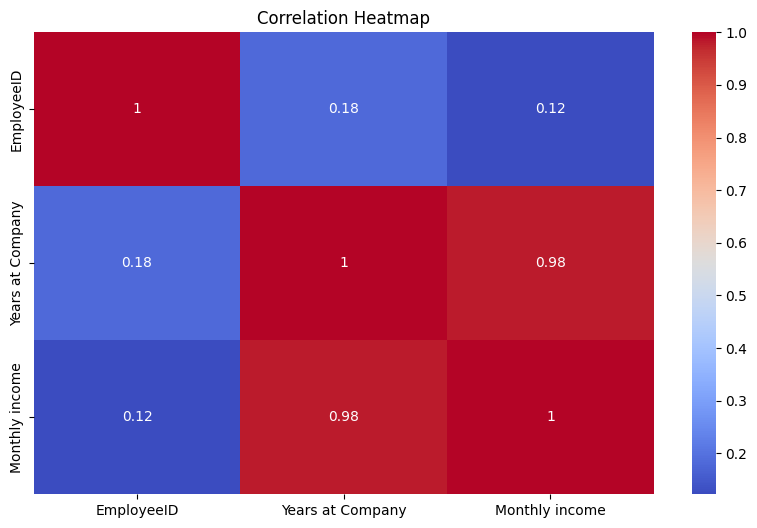


Analysis Completed Successfully


In [ ]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

print("\nAnalysis Completed Successfully")